# rocSPARSE `rocsparse-test` Log Analysis

Source data (read directly, not cached copies):
- `rocsparse-test.stdout` — 40+MB Google Test log, ~483k lines, 216,410 parsed test records
- `rocsparse-test.stderr` — near_check tolerance warnings + the fatal HW exception

**Headline finding:** the run scheduled 310,983 tests. Only 216,390 ever got a `[ RUN ]` line.
The process was killed mid-suite (`nightly/spmm_bsr`, 64 tests in, `Error allocating 2458967808 bytes (2 GB)`
immediately followed by `HW Exception ... reason :GPU Hang`) — matching `rocsparse_test_logging.sh`,
which runs the binary once, redirects stdout/stderr, and just propagates whatever exit code comes back.
94,593 tests (30% of the suite) never ran at all.

All parsing below is a single streaming pass over the log (regex line-by-line, never a full read into memory).

In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

STDOUT_PATH = "/home/netherquark/Soham/Large_code/sources/GPU/backrocm/graphs/gpus-14/error_logs/rocsparse-test.stdout"
STDERR_PATH = "/home/netherquark/Soham/Large_code/sources/GPU/backrocm/graphs/gpus-14/error_logs/rocsparse-test.stderr"

# ---- shared plot style, lifted from rocm-examples_plotting.ipynb ----
sns.set_theme(style="whitegrid")
plt.rcParams["font.family"] = "Adwaita Sans"
SUCCESS_BLUE = "#2c7bb6"
EXTRA_GREEN  = "#1a9850"
FAILURE_RED  = "#d7191c"
DNF_ORANGE   = "#fdae61"
NA_GREY      = "#888888"

RUN_RE = re.compile(r'^\[ RUN      \] (\S+)$')
OK_RE = re.compile(r'^\[       OK \] (\S+) \((\d+) ms\)$')
FAILED_RE = re.compile(r'^\[  FAILED  \] (\S+),')
SUITE_START_RE = re.compile(r'^\[----------\] (\d+) tests from (\S+)$')
SUITE_END_RE = re.compile(r'^\[----------\] (\d+) tests from (\S+) \((\d+) ms total\)$')
JUSTMS_RE = re.compile(r'^\s*\((\d+) ms\)$')
OPENFILE_RE = re.compile(r"^Opening file '.*/matrices/(\S+)\.csr' \.\.\. $")
SKIP_RE = re.compile(r'^Skipping test (\S+) because insufficient memory avaiable\.')
TOTAL_SCHEDULED_RE = re.compile(r'^\[==========\] Running (\d+) tests from (\d+) test suites\.$')

tests, suites = [], []
cur_matrix, cur_name, pending_failed, total_scheduled = None, None, None, None

with open(STDOUT_PATH, "r", errors="replace") as f:
    for line in f:
        line = line.rstrip("\n")
        if total_scheduled is None:
            m = TOTAL_SCHEDULED_RE.match(line)
            if m:
                total_scheduled = int(m.group(1))
                continue
        if SKIP_RE.match(line):
            tests.append({"full_name": SKIP_RE.match(line).group(1), "status": "SKIPPED_MEM", "time_ms": None, "matrix": None})
            continue
        m = SUITE_END_RE.match(line)
        if m:
            suites.append({"suite": m.group(2), "n_tests": int(m.group(1)), "total_ms": int(m.group(3)), "completed": True})
            continue
        m = SUITE_START_RE.match(line)
        if m:
            suites.append({"suite": m.group(2), "n_tests": int(m.group(1)), "total_ms": None, "completed": False})
            continue
        m = RUN_RE.match(line)
        if m:
            cur_name, cur_matrix = m.group(1), None
            continue
        m = OPENFILE_RE.match(line)
        if m:
            cur_matrix = m.group(1)
            continue
        m = OK_RE.match(line)
        if m:
            tests.append({"full_name": m.group(1), "status": "OK", "time_ms": int(m.group(2)), "matrix": cur_matrix})
            cur_name = None
            continue
        m = FAILED_RE.match(line)
        if m:
            pending_failed = (m.group(1), cur_matrix)
            continue
        m = JUSTMS_RE.match(line)
        if m and pending_failed:
            tests.append({"full_name": pending_failed[0], "status": "FAILED", "time_ms": int(m.group(1)), "matrix": pending_failed[1]})
            pending_failed = None
            continue

if cur_name:
    # process died with this test mid-flight -- the GPU Hang victim
    tests.append({"full_name": cur_name, "status": "CRASHED", "time_ms": None, "matrix": cur_matrix})

df = pd.DataFrame(tests)
suites_df = pd.DataFrame(suites)

def _parse_name(name):
    try:
        cat, rest = name.split("/", 1)
        suite, sub = rest.split(".", 1)
        return pd.Series([cat, suite, sub])
    except Exception:
        return pd.Series([None, None, None])

df[["category", "suite", "subtest"]] = df["full_name"].apply(_parse_name)
df["level"] = df["subtest"].str.extract(r'^(level\d)/')
df["prec"] = np.where(df["full_name"].str.contains("f64"), "f64",
              np.where(df["full_name"].str.contains("f32"), "f32", "other"))
df["is_complex"] = df["full_name"].str.contains(r"f3[24]_c|f64_c", regex=True)
suites_df[["category", "suite_name"]] = suites_df["suite"].str.split("/", n=1, expand=True)

N_SCHEDULED = total_scheduled or 310983
N_OK = int((df["status"] == "OK").sum())
N_FAILED = int((df["status"] == "FAILED").sum())
N_CRASHED = int((df["status"] == "CRASHED").sum())
N_SKIPPED_MEM = int((df["status"] == "SKIPPED_MEM").sum())
N_EXECUTED = N_OK + N_FAILED + N_CRASHED
N_NEVER_RUN = N_SCHEDULED - N_EXECUTED

print(f"scheduled={N_SCHEDULED:,}  executed={N_EXECUTED:,}  ok={N_OK:,}  "
      f"failed={N_FAILED}  crashed_by_hang={N_CRASHED}  "
      f"skipped_low_mem={N_SKIPPED_MEM}  never_run={N_NEVER_RUN:,}")


scheduled=310,983  executed=216,390  ok=216,388  failed=1  crashed_by_hang=1  skipped_low_mem=20  never_run=94,593


## Graph 1 — Overall Outcome
What happened to all 310,983 scheduled tests: passed, never reached because the run died, or actually failed/crashed.

/tmp/ipykernel_356263/2151595457.py:39: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(pad=2.0)


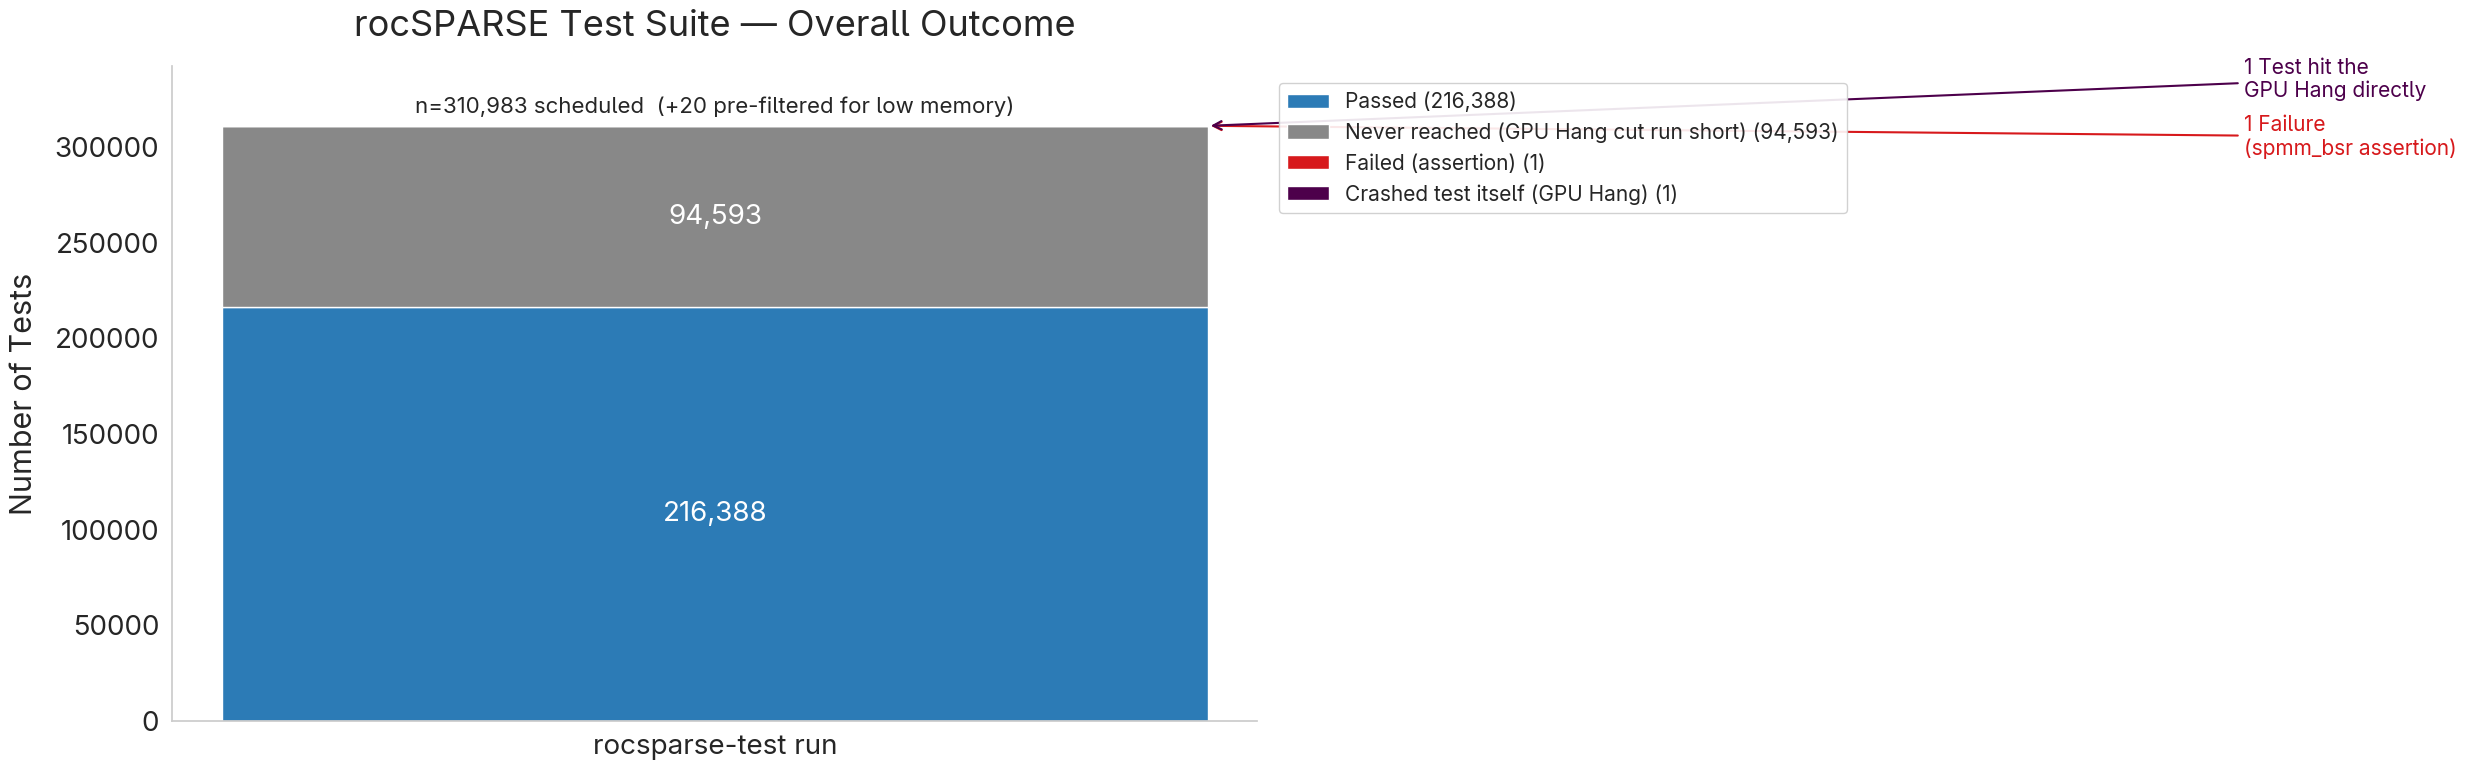

In [2]:
n_scheduled = N_SCHEDULED
labels = ["rocsparse-test run"]
segs = [
    ("Passed", N_OK, SUCCESS_BLUE),
    ("Never reached (GPU Hang cut run short)", N_NEVER_RUN, NA_GREY),
    ("Failed (assertion)", N_FAILED, FAILURE_RED),
    ("Crashed test itself (GPU Hang)", N_CRASHED, "#4d004b"),
]

fig, ax = plt.subplots(figsize=(14, 8.5))
bottom = 0
for name, val, color in segs:
    ax.bar(labels, [val], bottom=[bottom], color=color, label=f"{name} ({val:,})", width=0.4)
    if val > 4000:
        ax.text(0, bottom + val/2, f"{val:,}", ha="center", va="center", fontsize=20, color="white", fontweight="normal")
    bottom += val

fail_y = N_OK + N_NEVER_RUN + N_FAILED/2
crash_y = N_OK + N_NEVER_RUN + N_FAILED + N_CRASHED/2
ax.annotate("1 Failure\n(spmm_bsr assertion)", xy=(0.2, fail_y), xytext=(0.62, fail_y - 15000),
            fontsize=15, ha="left", color=FAILURE_RED,
            arrowprops=dict(arrowstyle="->", color=FAILURE_RED, lw=1.5))
ax.annotate("1 Test hit the\nGPU Hang directly", xy=(0.2, crash_y), xytext=(0.62, crash_y + 15000),
            fontsize=15, ha="left", color="#4d004b",
            arrowprops=dict(arrowstyle="->", color="#4d004b", lw=1.5))

ax.set_ylim(0, n_scheduled * 1.1)
ax.set_title("rocSPARSE Test Suite — Overall Outcome", fontsize=26, pad=22)
ax.set_ylabel("Number of Tests", fontsize=22, labelpad=12)
ax.set_xlabel("")
ax.set_xticks([0]); ax.set_xticklabels(labels, fontsize=20)
ax.tick_params(axis="y", labelsize=20)
ax.text(0, bottom + n_scheduled*0.015, f"n={n_scheduled:,} scheduled  (+{N_SKIPPED_MEM} pre-filtered for low memory)",
        ha="center", va="bottom", fontsize=16)
legend = ax.legend(loc="upper left", bbox_to_anchor=(1.01, 0.99), fontsize=15, framealpha=0.9)
for t in legend.get_texts(): t.set_fontfamily("Adwaita Sans")
ax.grid(False)
sns.despine(ax=ax, top=True, right=True, left=False, bottom=False)
plt.tight_layout(pad=2.0)
plt.savefig("01_overall_outcome.png", dpi=300, bbox_inches="tight")
plt.show()

## Graph 2 — Executed Tests by Category
googletest groups tests into `quick`, `pre_checkin`, `nightly`, `stress`. Shows the relative weight of each.

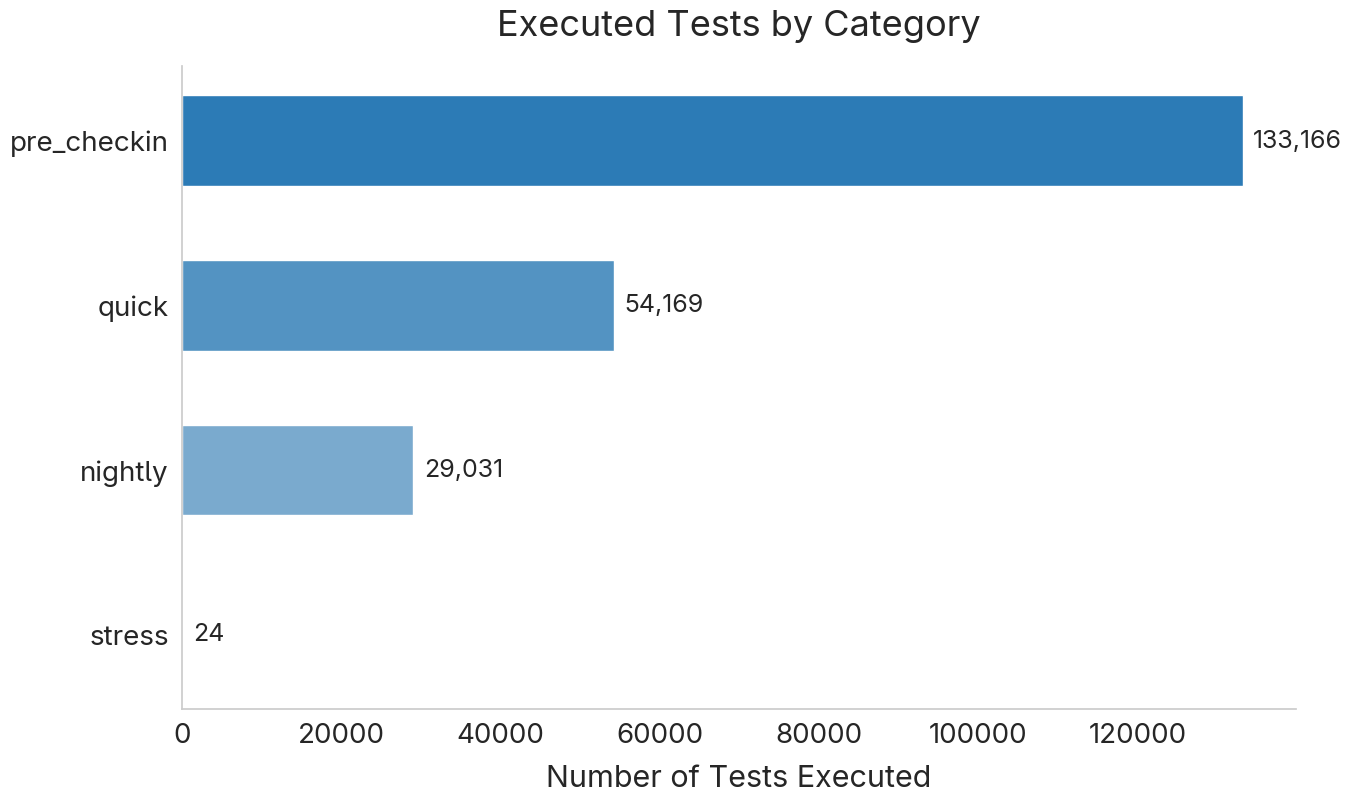

In [3]:
executed = df[df["status"].isin(["OK", "FAILED", "CRASHED"])]
counts = executed["category"].value_counts().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(14, 8.5))
colors = sns.light_palette(SUCCESS_BLUE, n_colors=len(counts) + 2)[2:]
bars = ax.barh(counts.index, counts.values, color=colors, height=0.55)
for b, v in zip(bars, counts.values):
    ax.text(v + max(counts.values) * 0.01, b.get_y() + b.get_height() / 2, f"{v:,}", va="center", fontsize=18)
ax.set_title("Executed Tests by Category", fontsize=26, pad=22)
ax.set_xlabel("Number of Tests Executed", fontsize=22, labelpad=12)
ax.set_ylabel("")
ax.tick_params(axis="both", labelsize=20)
ax.grid(False); sns.despine(ax=ax, top=True, right=True)
plt.tight_layout(pad=2.0)
plt.savefig("02_category_breakdown.png", dpi=300, bbox_inches="tight")
plt.show()

## Graph 3 — Where the Run Died (Sankey)
Flow from every scheduled test down to what actually happened to it. Makes the 94,593 never-run tests visually impossible to miss.

In [17]:
import plotly.graph_objects as go

root = f"Scheduled ({N_SCHEDULED:,})"
executed_n = f"Executed ({N_EXECUTED:,})"
never_n = f"Never Run — GPU Hang ({N_NEVER_RUN:,})"
ok_n = f"Passed ({N_OK:,})"
fail_n = f"Failed ({N_FAILED:,})"
crash_n = f"Crashed process ({N_CRASHED:,})"

nodes = [root, executed_n, never_n, ok_n, fail_n, crash_n]
idx = {n: i for i, n in enumerate(nodes)}
node_x = [0.001, 0.4, 0.4, 0.999, 0.999, 0.999]
node_y = [0.5, 0.25, 0.85, 0.15, 0.5, 0.7]
color_map = {"neutral": "rgba(100, 116, 139, 0.85)", "success": "rgba(44, 123, 182, 0.85)",
             "failure": "rgba(215, 25, 28, 0.85)", "hang": "rgba(77, 0, 75, 0.85)"}
node_colors = [color_map["neutral"], color_map["success"], color_map["hang"],
               color_map["success"], color_map["failure"], color_map["hang"]]
flows = [(root, executed_n, N_EXECUTED), (root, never_n, N_NEVER_RUN),
         (executed_n, ok_n, N_OK), (executed_n, fail_n, N_FAILED), (executed_n, crash_n, N_CRASHED)]
link_colors = ["rgba(44,123,182,0.30)", "rgba(77,0,75,0.30)",
               "rgba(44,123,182,0.30)", "rgba(215,25,28,0.30)", "rgba(77,0,75,0.30)"]

fig = go.Figure(data=[go.Sankey(
    arrangement="snap",
    node=dict(pad=20, thickness=20, line=dict(color="rgba(255,255,255,0.9)", width=0.5),
              label=nodes, color=node_colors, x=node_x, y=node_y),
    link=dict(source=[idx[s] for s, t, v in flows], target=[idx[t] for s, t, v in flows],
              value=[v for s, t, v in flows], color=link_colors),
)])
fig.update_layout(
    title_text="rocSPARSE Test classification",
    title_font=dict(size=24, family="Adwaita Mono, monospace", color="#1e293b"),
    font_size=16, font_family="Adwaita Sans, sans-serif",
    width=1400, height=850, plot_bgcolor="white", paper_bgcolor="white",
)
fig.write_image("03_sankey_crash.png", scale=2)
fig.show()

## Graph 4 — Individual Test Runtime Distribution
Most tests are near-instant; a long tail of expensive ones drags the mean up (mean 84ms vs median 4ms).

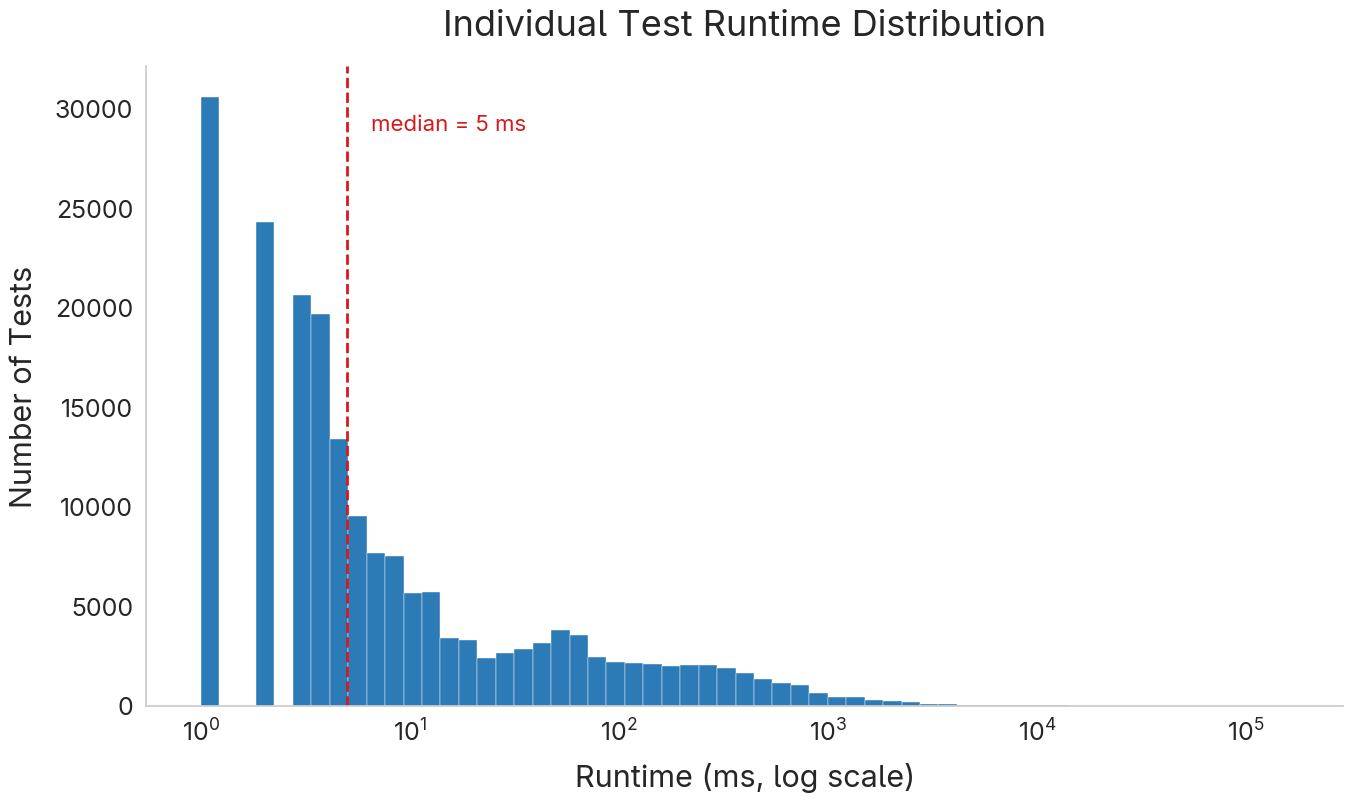

In [5]:
t = df[df["time_ms"].notna() & (df["time_ms"] > 0)]["time_ms"]

fig, ax = plt.subplots(figsize=(14, 8.5))
bins = np.logspace(0, np.log10(t.max()), 60)
ax.hist(t, bins=bins, color=SUCCESS_BLUE, edgecolor="white", linewidth=0.3)
ax.set_xscale("log")
ax.set_title("Individual Test Runtime Distribution", fontsize=26, pad=22)
ax.set_xlabel("Runtime (ms, log scale)", fontsize=22, labelpad=12)
ax.set_ylabel("Number of Tests", fontsize=22, labelpad=12)
ax.tick_params(axis="both", labelsize=18)
median = t.median()
ax.axvline(median, color=FAILURE_RED, linestyle="--", linewidth=2)
ax.text(median * 1.3, ax.get_ylim()[1] * 0.9, f"median = {median:.0f} ms", fontsize=16, color=FAILURE_RED)
ax.grid(False); sns.despine(ax=ax, top=True, right=True)
plt.tight_layout(pad=2.0)
plt.savefig("04_runtime_hist.png", dpi=300, bbox_inches="tight")
plt.show()

## Graph 5 — Runtime by Category (log-scale boxplot)
`nightly` tests use much bigger real-world matrices than `quick`/`pre_checkin`, so their time distribution shifts up and widens.

/tmp/ipykernel_356263/3083597902.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=t, x="category", y="time_ms", order=order, ax=ax, palette=palette,


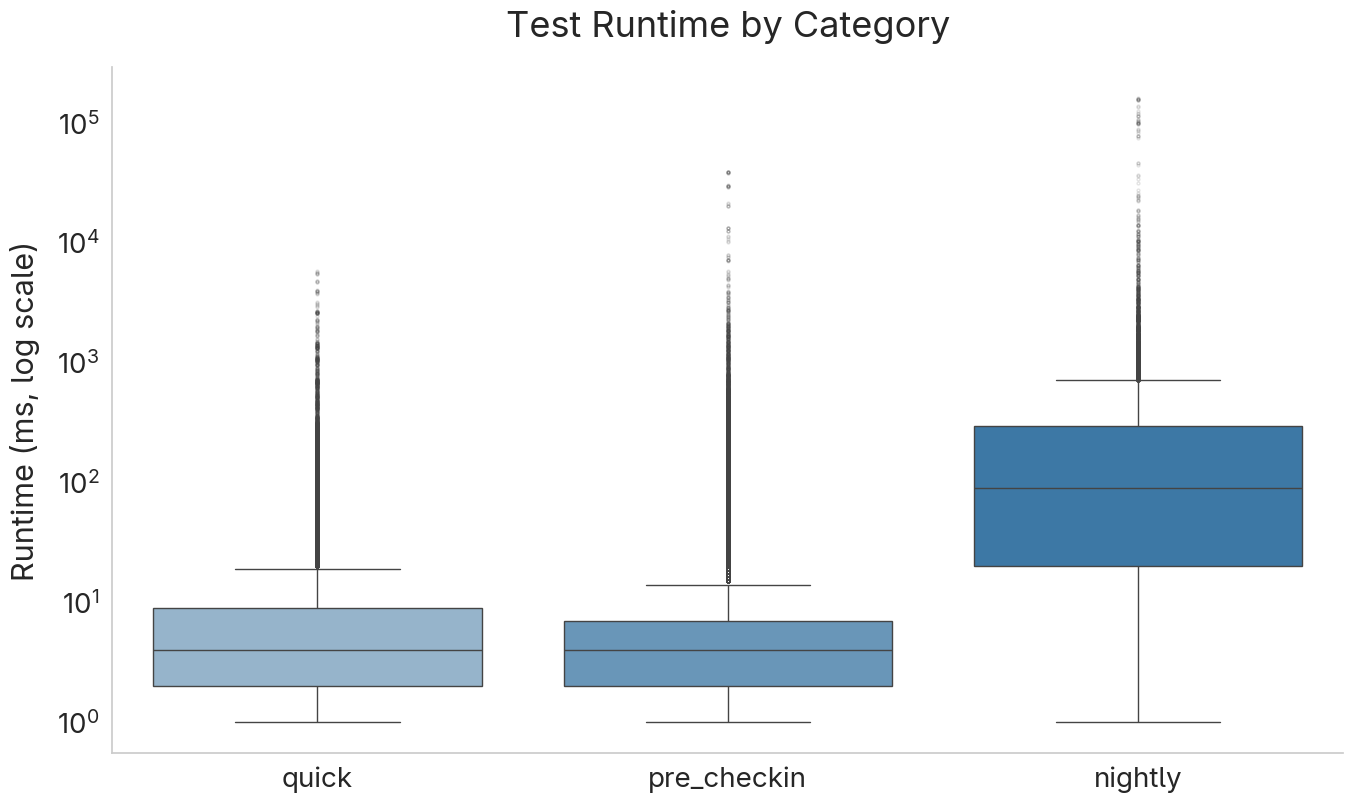

In [6]:
t = df[df["time_ms"].notna() & (df["time_ms"] > 0) & df["category"].isin(["quick", "pre_checkin", "nightly"])].copy()

fig, ax = plt.subplots(figsize=(14, 8.5))
order = ["quick", "pre_checkin", "nightly"]
palette = sns.light_palette(SUCCESS_BLUE, n_colors=5)[2:]
sns.boxplot(data=t, x="category", y="time_ms", order=order, ax=ax, palette=palette,
            showfliers=True, flierprops=dict(marker="o", markersize=2, alpha=0.15, color="#555555"))
ax.set_yscale("log")
ax.set_title("Test Runtime by Category", fontsize=26, pad=22)
ax.set_xlabel("", fontsize=22)
ax.set_ylabel("Runtime (ms, log scale)", fontsize=22, labelpad=12)
ax.tick_params(axis="both", labelsize=20)
ax.grid(False); sns.despine(ax=ax, top=True, right=True)
plt.tight_layout(pad=2.0)
plt.savefig("05_box_by_category.png", dpi=300, bbox_inches="tight")
plt.show()

## Graph 6 — Top 20 Slowest Individual Tests
All dominated by `csritsv` (iterative triangular solve) on the `bmwcra_1` matrix, plus one `bsric0` outlier.

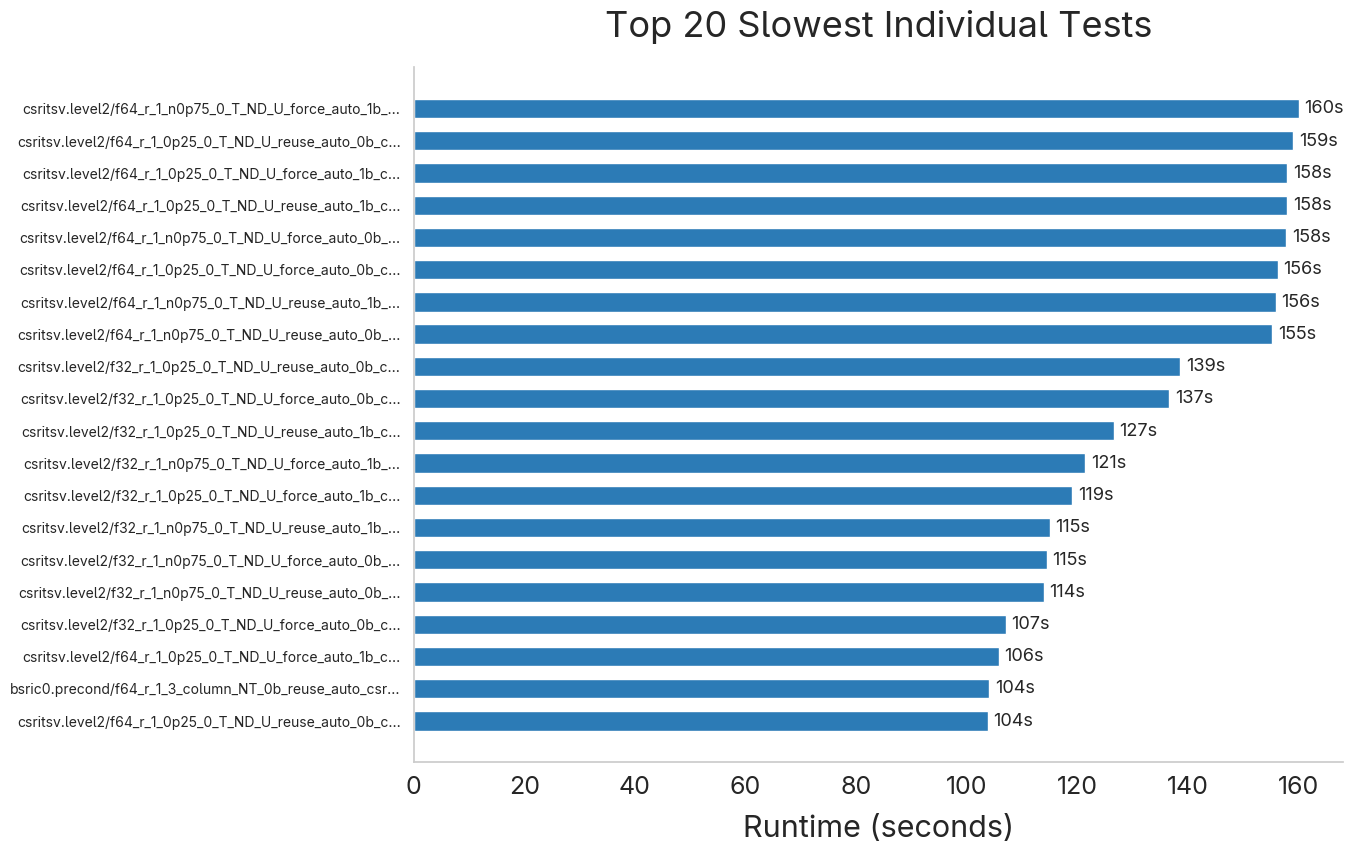

In [7]:
top20 = df.nlargest(20, "time_ms")[["full_name", "time_ms", "status", "matrix"]].iloc[::-1].reset_index(drop=True)
colors = [FAILURE_RED if s == "FAILED" else SUCCESS_BLUE for s in top20["status"]]
short = [n.split("/", 1)[1][:52] + ("..." if len(n.split("/", 1)[1]) > 52 else "") for n in top20["full_name"]]
y = range(len(top20))

fig, ax = plt.subplots(figsize=(14, 9))
bars = ax.barh(list(y), top20["time_ms"] / 1000, color=colors, height=0.6)
for yi, v in zip(y, top20["time_ms"] / 1000):
    ax.text(v + 1, yi, f"{v:.0f}s", va="center", fontsize=13)
ax.set_yticks(list(y)); ax.set_yticklabels(short, fontsize=10)
ax.set_title("Top 20 Slowest Individual Tests", fontsize=26, pad=22)
ax.set_xlabel("Runtime (seconds)", fontsize=22, labelpad=12)
ax.tick_params(axis="x", labelsize=18)
ax.grid(False); sns.despine(ax=ax, top=True, right=True)
plt.tight_layout(pad=2.0)
plt.savefig("06_slowest_tests.png", dpi=300, bbox_inches="tight")
plt.show()

## Graph 7 — Top 15 Suites by Total GPU Time
Which test suites (summed across all categories) actually burned the most wall-clock GPU time.

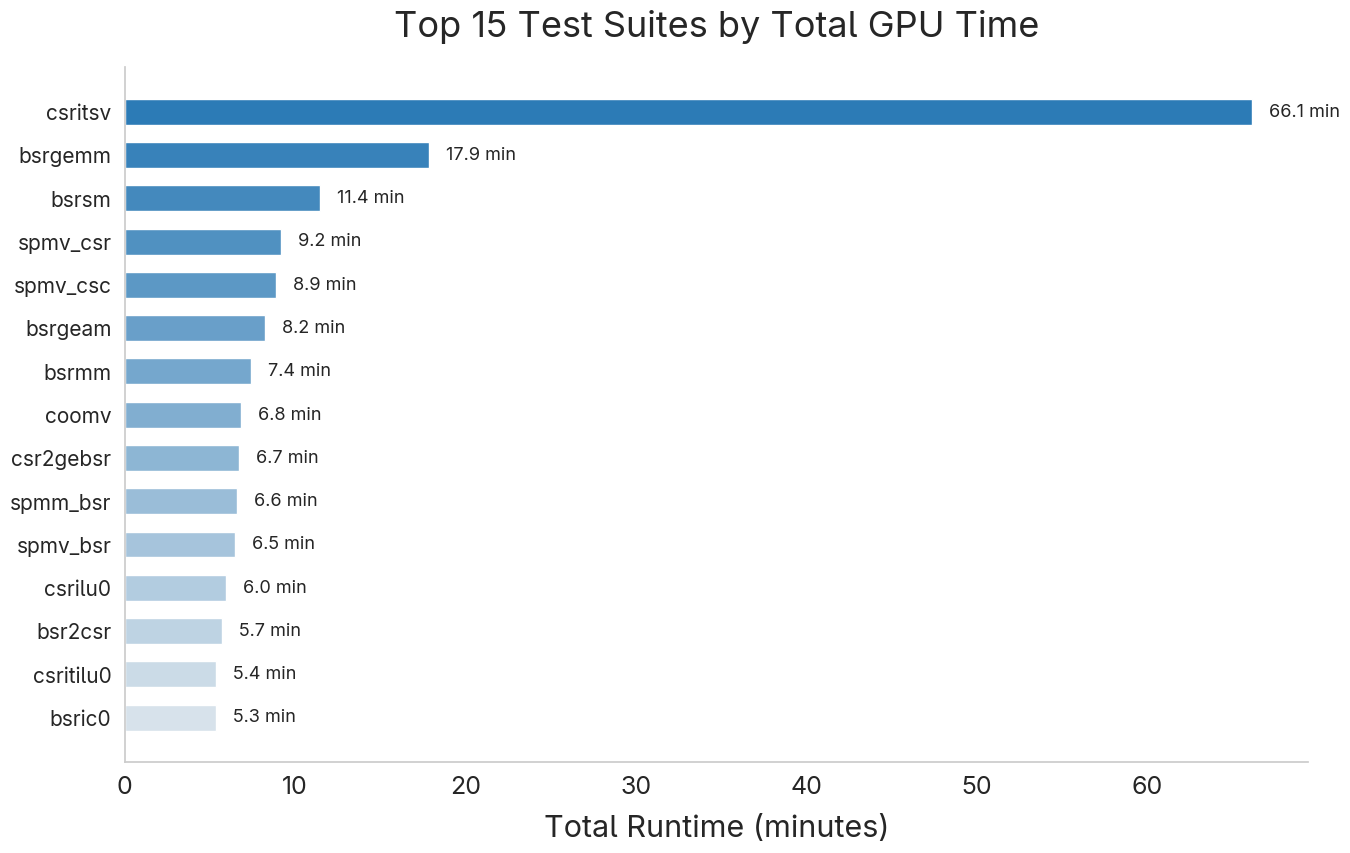

In [8]:
g = df.groupby("suite")["time_ms"].sum().sort_values(ascending=True).tail(15)
fig, ax = plt.subplots(figsize=(14, 9))
y = range(len(g))
colors = sns.light_palette(SUCCESS_BLUE, n_colors=len(g) + 2)[2:]
ax.barh(list(y), g.values / 1000 / 60, color=colors, height=0.6)
for yi, v in zip(y, g.values / 1000 / 60):
    ax.text(v + 1, yi, f"{v:.1f} min", va="center", fontsize=13)
ax.set_yticks(list(y)); ax.set_yticklabels(g.index, fontsize=15)
ax.set_title("Top 15 Test Suites by Total GPU Time", fontsize=26, pad=22)
ax.set_xlabel("Total Runtime (minutes)", fontsize=22, labelpad=12)
ax.tick_params(axis="x", labelsize=18)
ax.grid(False); sns.despine(ax=ax, top=True, right=True)
plt.tight_layout(pad=2.0)
plt.savefig("07_top_suites_by_time.png", dpi=300, bbox_inches="tight")
plt.show()

## Graph 8 — Suite Hierarchy Treemap
Size = test count, color = avg ms/test. Lets you spot suites that are both huge *and* slow at a glance (e.g. `spmm_bsr` nightly).

In [9]:
import plotly.graph_objects as go

comp = suites_df.dropna(subset=["total_ms"]).copy()
comp = comp[comp["category"].isin(["quick", "pre_checkin", "nightly", "stress"])]
comp["avg_ms"] = comp["total_ms"] / comp["n_tests"]

fig = go.Figure(go.Treemap(
    labels=comp["suite_name"] + " (" + comp["category"] + ")",
    parents=comp["category"],
    values=comp["n_tests"],
    marker=dict(colors=comp["avg_ms"], colorscale=[[0, "#2c7bb6"], [0.5, "#fdae61"], [1, "#d7191c"]],
                colorbar=dict(title="avg ms/test")),
    text=comp["suite_name"],
    hovertemplate="%{label}<br>tests=%{value}<br>avg=%{marker.color:.1f} ms<extra></extra>",
))
fig.update_layout(
    title_text="Suite Hierarchy: Test Count (size) vs Avg Runtime (color)",
    title_font=dict(size=24, family="Adwaita Mono, monospace", color="#1e293b"),
    font_size=14, font_family="Adwaita Sans, sans-serif",
    width=1400, height=850, paper_bgcolor="white",
)
fig.write_image("08_treemap.png", scale=2)
fig.show()

## Graph 9 — Suite Efficiency Scatter
Test count vs total GPU time per suite, log-log, colored by category. Suites above the trend are disproportionately expensive for their size.

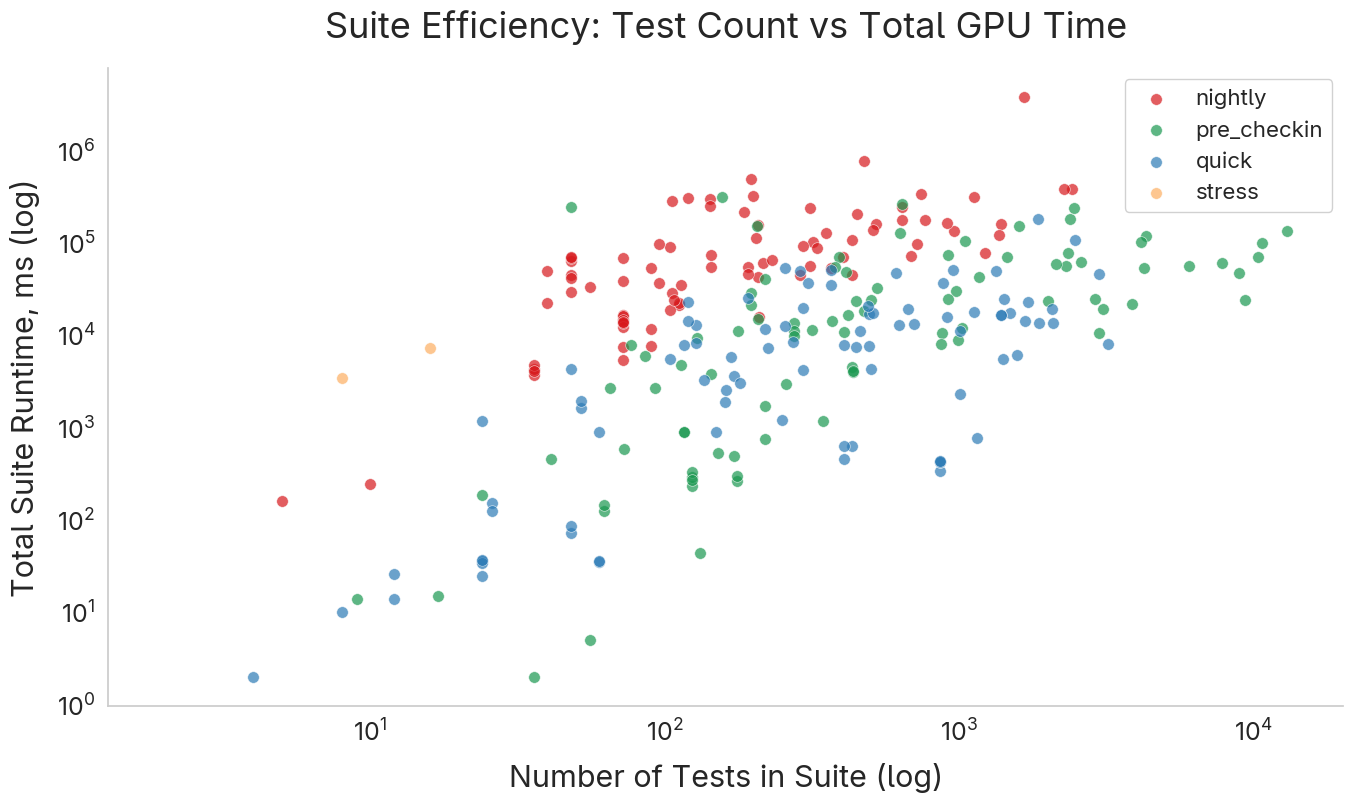

In [10]:
cat_colors = {"quick": SUCCESS_BLUE, "pre_checkin": EXTRA_GREEN, "nightly": FAILURE_RED, "stress": DNF_ORANGE}
comp = suites_df.dropna(subset=["total_ms"]).copy()
comp = comp[comp["category"].isin(["quick", "pre_checkin", "nightly", "stress"])]

fig, ax = plt.subplots(figsize=(14, 8.5))
for cat, sub in comp.groupby("category"):
    ax.scatter(sub["n_tests"], sub["total_ms"], s=70, alpha=0.7, color=cat_colors[cat], label=cat,
               edgecolor="white", linewidth=0.5)
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_title("Suite Efficiency: Test Count vs Total GPU Time", fontsize=26, pad=22)
ax.set_xlabel("Number of Tests in Suite (log)", fontsize=22, labelpad=12)
ax.set_ylabel("Total Suite Runtime, ms (log)", fontsize=22, labelpad=12)
ax.tick_params(axis="both", labelsize=18)
legend = ax.legend(fontsize=16, framealpha=0.9)
for t in legend.get_texts(): t.set_fontfamily("Adwaita Sans")
ax.grid(False); sns.despine(ax=ax, top=True, right=True)
plt.tight_layout(pad=2.0)
plt.savefig("09_scatter_efficiency.png", dpi=300, bbox_inches="tight")
plt.show()

## Graph 10 — f32 vs f64 Precision Cost
Double precision costs ~40% more per test on average, and 45% more in aggregate GPU time.

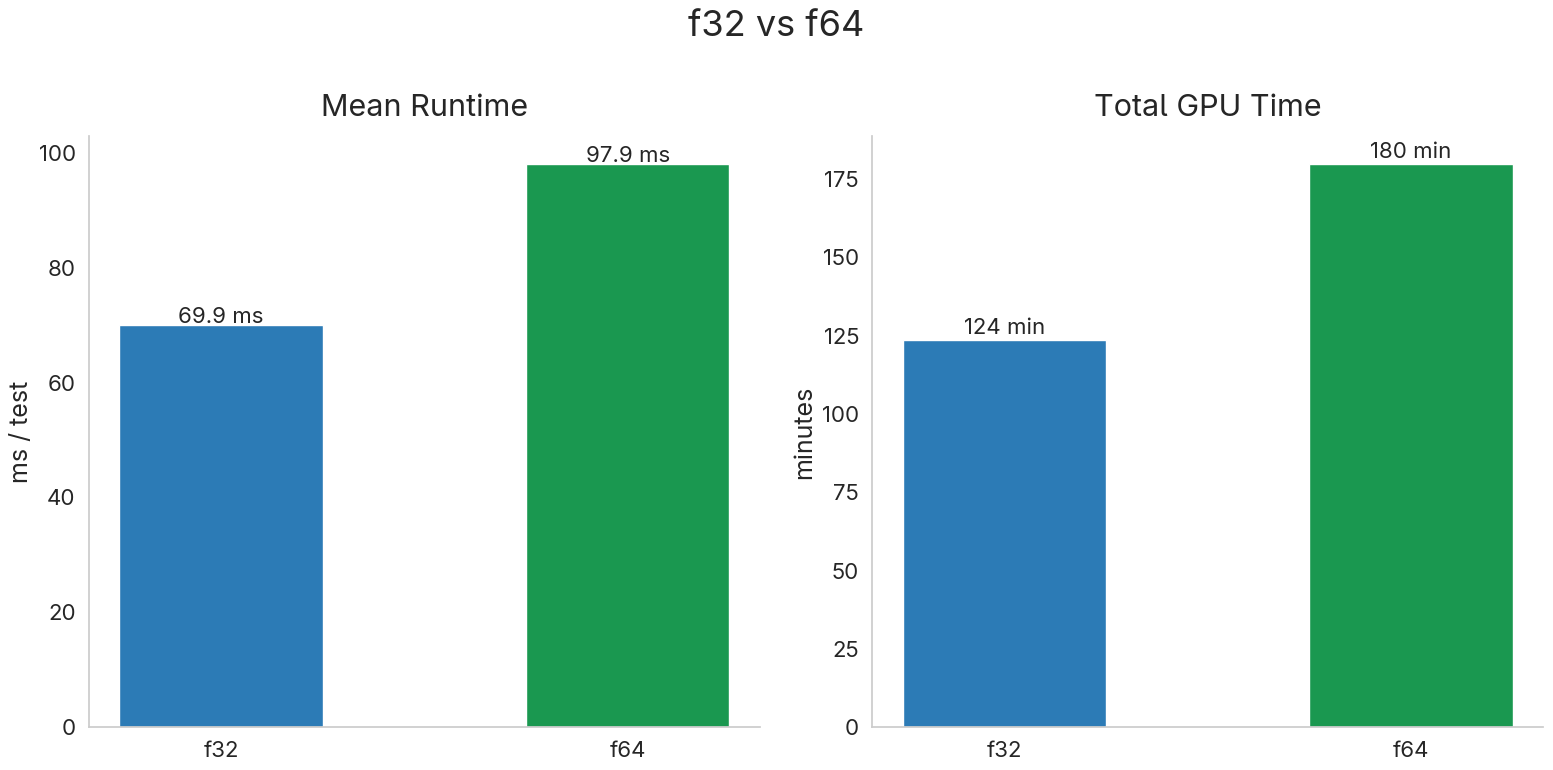

In [19]:
d = df[df["time_ms"].notna() & df["prec"].isin(["f32", "f64"])]
mean_t = d.groupby("prec")["time_ms"].mean()
total_t = d.groupby("prec")["time_ms"].sum() / 1000 / 60

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
labels = ["f32", "f64"]; colors = [SUCCESS_BLUE, EXTRA_GREEN]

axes[0].bar(labels, mean_t[labels], color=colors, width=0.5)
for i, v in enumerate(mean_t[labels]): axes[0].text(i, v + 0.5, f"{v:.1f} ms", ha="center", fontsize=16)
axes[0].set_title("Mean Runtime", fontsize=22, pad=15)
axes[0].set_ylabel("ms / test", fontsize=18); axes[0].tick_params(labelsize=16)

axes[1].bar(labels, total_t[labels], color=colors, width=0.5)
for i, v in enumerate(total_t[labels]): axes[1].text(i, v + 2, f"{v:.0f} min", ha="center", fontsize=16)
axes[1].set_title("Total GPU Time", fontsize=22, pad=15)
axes[1].set_ylabel("minutes", fontsize=18); axes[1].tick_params(labelsize=16)

for ax in axes:
    ax.grid(False); sns.despine(ax=ax, top=True, right=True)
fig.suptitle("f32 vs f64", fontsize=26)
plt.tight_layout(pad=2.0)
plt.savefig("10_precision_compare.png", dpi=300, bbox_inches="tight")
plt.show()

## Graph 11 — Real vs Complex Number Types
Share of executed tests using complex (`_c`) vs real arithmetic.

In [20]:
import plotly.graph_objects as go

d = df[df["status"].isin(["OK", "FAILED"])]
n_complex = int(d["is_complex"].sum())
n_real = len(d) - n_complex

fig = go.Figure(go.Pie(
    labels=[f"Real ({n_real:,})", f"Complex ({n_complex:,})"],
    values=[n_real, n_complex],
    hole=0.55,
    marker=dict(colors=["#2c7bb6", "#d7191c"], line=dict(color="white", width=2)),
    textinfo="label+percent",
    textfont=dict(size=18, family="Adwaita Sans, sans-serif"),
))
fig.update_layout(
    title_text="Real vs Complex Tests",
    title_font=dict(size=24, family="Adwaita Mono, monospace", color="#1e293b"),
    font_size=16, font_family="Adwaita Sans, sans-serif",
    width=900, height=750, paper_bgcolor="white", showlegend=False,
)
fig.write_image("11_donut.png", scale=2)
fig.show()

## Graph 12 — Tests by BLAS Level
Sparse routines classify as level1 (vector), level2 (matrix-vector), level3 (matrix-matrix), or format/misc ops with no level.

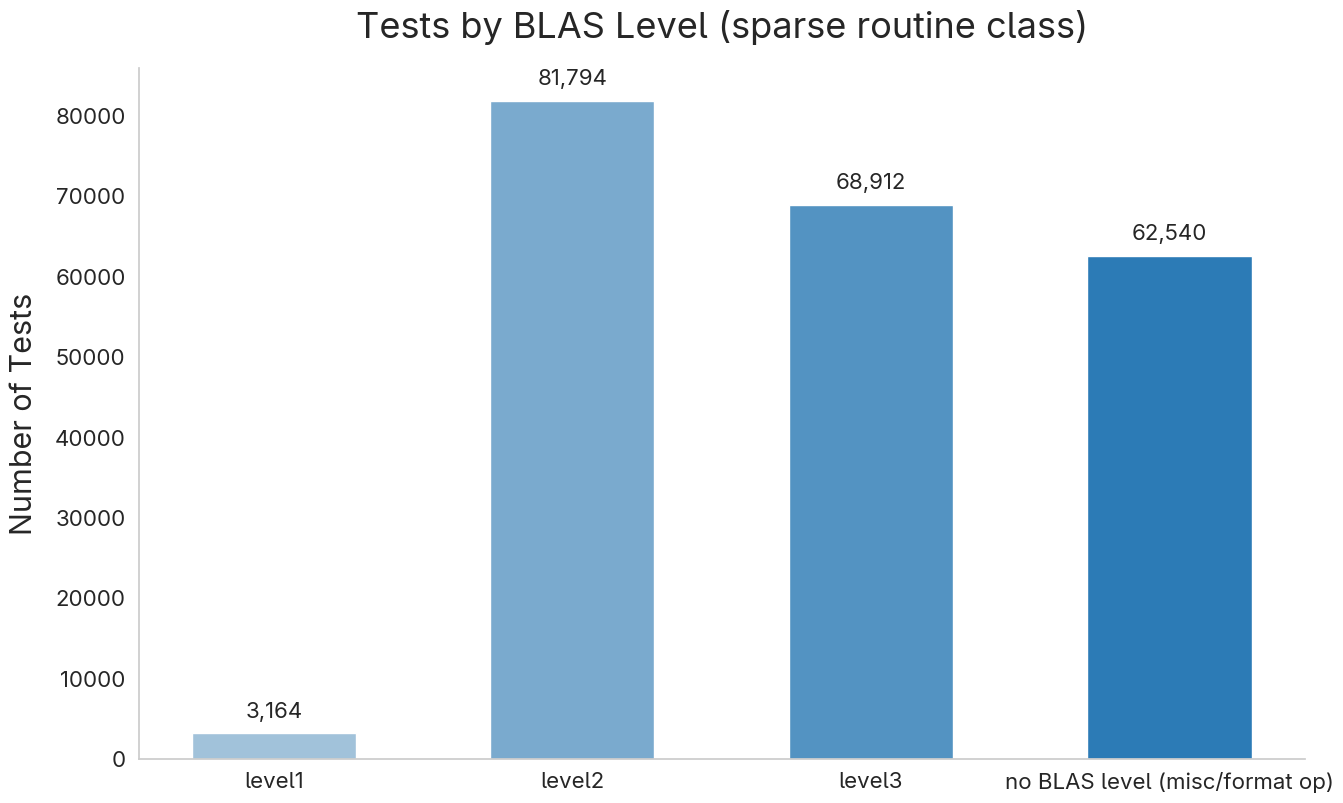

In [13]:
lv = df["level"].fillna("no BLAS level (misc/format op)").value_counts()
order = ["level1", "level2", "level3", "no BLAS level (misc/format op)"]
lv = lv.reindex(order)

fig, ax = plt.subplots(figsize=(14, 8.5))
colors = sns.light_palette(SUCCESS_BLUE, n_colors=6)[2:]
bars = ax.bar(lv.index, lv.values, color=colors, width=0.55)
for b, v in zip(bars, lv.values):
    ax.text(b.get_x() + b.get_width() / 2, v + 2000, f"{v:,}", ha="center", fontsize=16)
ax.set_title("Tests by BLAS Level (sparse routine class)", fontsize=26, pad=22)
ax.set_ylabel("Number of Tests", fontsize=22, labelpad=12)
ax.tick_params(axis="both", labelsize=16)
ax.grid(False); sns.despine(ax=ax, top=True, right=True)
plt.tight_layout(pad=2.0)
plt.savefig("12_blas_level.png", dpi=300, bbox_inches="tight")
plt.show()

## Graph 13 — Top 20 Real-World Matrices Used
Lollipop chart of the most frequently exercised named matrices (`.csr` files) across the whole suite.

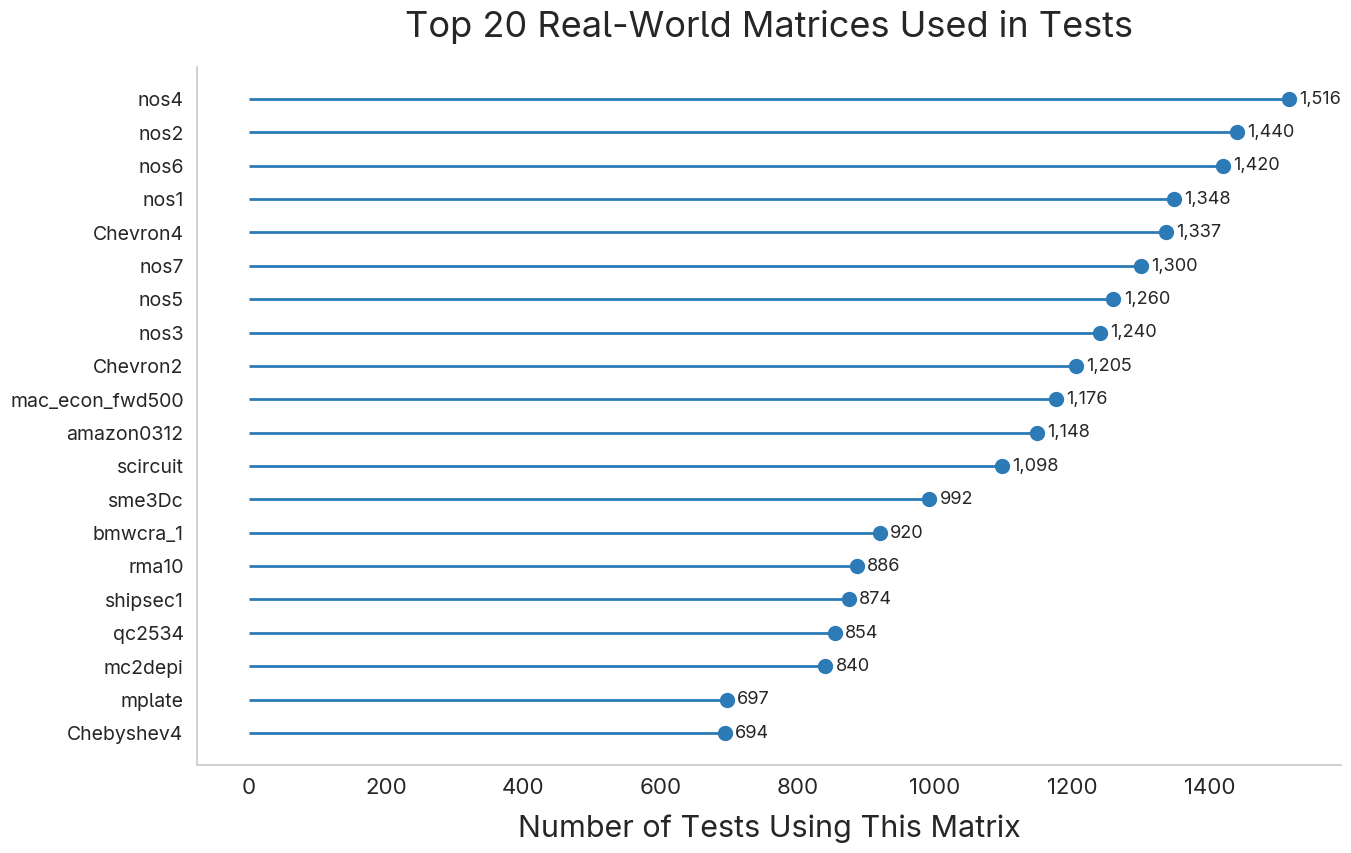

In [14]:
top20 = df["matrix"].value_counts().head(20).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(14, 9))
y = range(len(top20))
ax.hlines(y=list(y), xmin=0, xmax=top20.values, color=SUCCESS_BLUE, linewidth=2)
ax.plot(top20.values, list(y), "o", color=SUCCESS_BLUE, markersize=10)
for yi, v in zip(y, top20.values):
    ax.text(v + 15, yi, f"{v:,}", va="center", fontsize=13)
ax.set_yticks(list(y)); ax.set_yticklabels(top20.index, fontsize=14)
ax.set_title("Top 20 Real-World Matrices Used in Tests", fontsize=26, pad=22)
ax.set_xlabel("Number of Tests Using This Matrix", fontsize=22, labelpad=12)
ax.tick_params(axis="x", labelsize=16)
ax.grid(False); sns.despine(ax=ax, top=True, right=True)
plt.tight_layout(pad=2.0)
plt.savefig("13_matrix_lollipop.png", dpi=300, bbox_inches="tight")
plt.show()

## Graph 14 — Cumulative GPU Time to the Crash
Running total of GPU time across the execution sequence, with the exact point the GPU Hang killed the process marked.

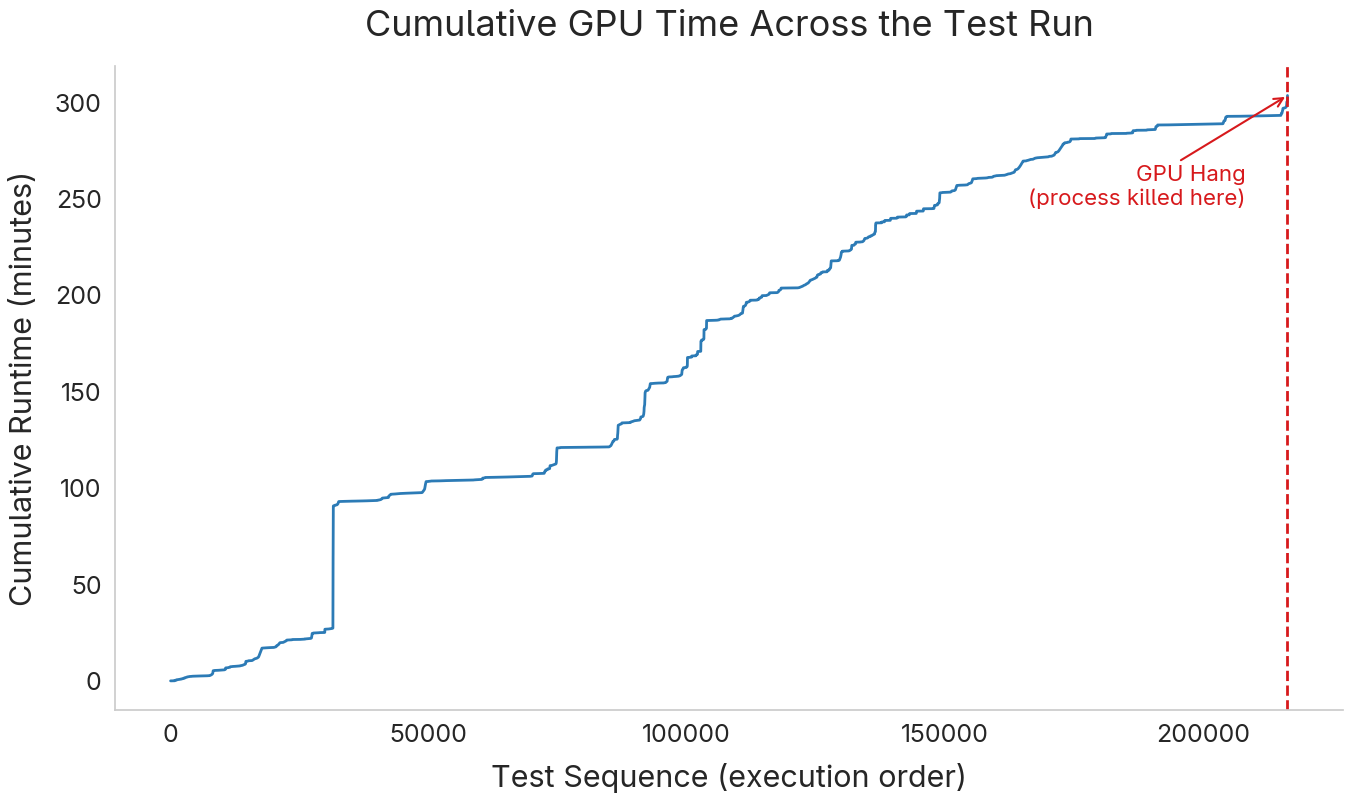

In [ ]:
dt = df[df["time_ms"].notna()].reset_index(drop=True)
dt["cum_min"] = dt["time_ms"].cumsum() / 1000 / 60

fig, ax = plt.subplots(figsize=(14, 8.5))
ax.plot(dt.index, dt["cum_min"], color=SUCCESS_BLUE, linewidth=2)
ax.axvline(len(dt) - 1, color=FAILURE_RED, linestyle="--", linewidth=2)

ax.annotate(
    "GPU Hang\n(process killed here)", 
    xy=(len(dt) - 1, dt["cum_min"].iloc[-1]),
    xytext=(-30, -50), 
    textcoords="offset points",
    ha="right", 
    va="top",
    fontsize=16, 
    color=FAILURE_RED,
    arrowprops=dict(arrowstyle="->", color=FAILURE_RED, lw=1.5)
)

ax.set_title("Cumulative GPU Time Across the Test Run", fontsize=26, pad=22)
ax.set_xlabel("Test Sequence (execution order)", fontsize=22, labelpad=12)
ax.set_ylabel("Cumulative Runtime (minutes)", fontsize=22, labelpad=12)
ax.tick_params(axis="both", labelsize=18)
ax.grid(False); sns.despine(ax=ax, top=True, right=True)
plt.tight_layout(pad=2.0)
plt.savefig("14_cumulative_time.png", dpi=300, bbox_inches="tight")
plt.show()

## Graph 15 — Suite x Category Avg-Time Heatmap
Top 12 slowest suites (by total time), average per-test ms split by category. Shows nightly consistently dwarfing quick/pre_checkin for the same suite.

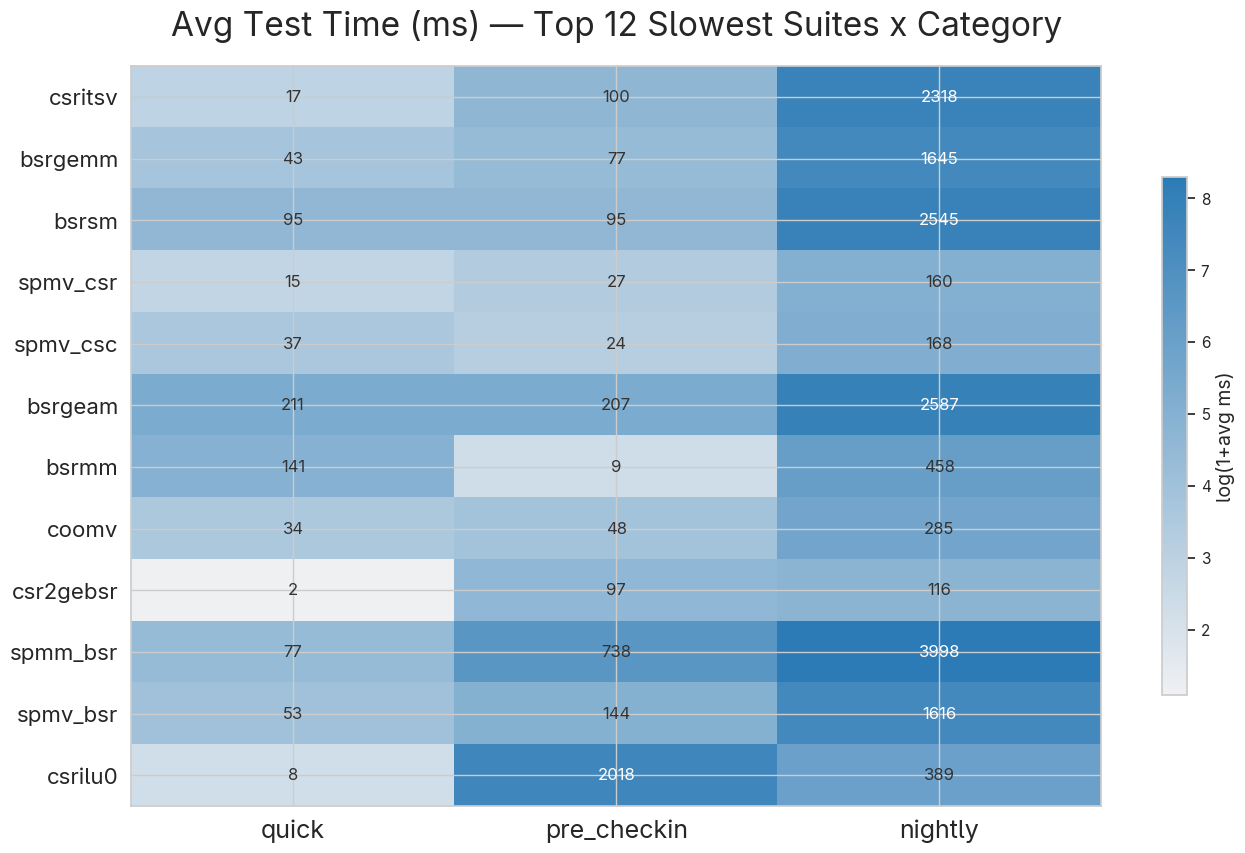

In [16]:
top_suites = df.groupby("suite")["time_ms"].sum().sort_values(ascending=False).head(12).index.tolist()
piv = df[df["suite"].isin(top_suites)].groupby(["suite", "category"])["time_ms"].mean().unstack()
piv = piv.reindex(top_suites)[["quick", "pre_checkin", "nightly"]]

fig, ax = plt.subplots(figsize=(14, 9))
cmap = sns.light_palette("#2c7bb6", as_cmap=True)
im = ax.imshow(np.log1p(piv.values), cmap=cmap, aspect="auto")
ax.set_xticks(range(3)); ax.set_xticklabels(["quick", "pre_checkin", "nightly"], fontsize=18)
ax.set_yticks(range(len(piv))); ax.set_yticklabels(piv.index, fontsize=16)
for i in range(piv.shape[0]):
    for j in range(piv.shape[1]):
        v = piv.values[i, j]
        if not np.isnan(v):
            ax.text(j, i, f"{v:.0f}", ha="center", va="center", fontsize=12,
                    color="white" if v > np.nanmax(piv.values) * 0.4 else "#333333")
ax.set_title("Avg Test Time (ms) — Top 12 Slowest Suites x Category", fontsize=24, pad=22)
cbar = fig.colorbar(im, ax=ax, shrink=0.7); cbar.set_label("log(1+avg ms)", fontsize=14)
plt.tight_layout(pad=2.0)
plt.savefig("15_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()